In [7]:
import data

import typing as tt
import pandas as pd
import numpy as np
import tqdm
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, 
    roc_auc_score, auc, precision_recall_curve
)
from PIL import Image

import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default = 'plotly_white'

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        if in_channels != out_channels or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        x = self.main(x) + self.shortcut(x)
        return F.relu(x)


class Network(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            ResidualBlock(32, 32, stride=1),
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 128, stride=2),
            ResidualBlock(128, 128, stride=1),
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1),

            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),

            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

In [9]:
images_path = data.get_images_path()
images_classes = data.get_classes(images_path)
images_classes_en = data.get_english_classes(images_classes)

samples = data.get_sorted_samples(images_path)
train_samples, val_samples, test_samples = data.split_train_val_test(
    samples, seed=data.TRAIN_TEST_DEFAULT_SEED, shuffle=True)

In [10]:
model = Network(len(images_classes))
model.eval()
device = torch.device("cpu")
MODEL_NAME = "models/03-resnet-aug_best.model"
weights_dict = torch.load(MODEL_NAME, map_location=device, weights_only=True)
model.load_state_dict(weights_dict)

<All keys matched successfully>

In [11]:
BATCH_SIZE = 128
val_dataset = data.ImagesDataset(images_classes, val_samples)
val_loader = DataLoader(val_dataset, BATCH_SIZE)
test_dataset = data.ImagesDataset(images_classes, test_samples)
test_loader = DataLoader(test_dataset, BATCH_SIZE)

In [12]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    for batch_x, batch_y in tqdm.tqdm(test_loader):
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        true_classes.extend(batch_y.detach().numpy())
        pred_classes.extend(preds_t.detach().numpy())
        pred_probs.extend(probs_t.detach().numpy())
pred_probs = np.array(pred_probs)
pred_classes = np.array(pred_classes)
true_classes = np.array(true_classes)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:07<00:00,  3.54s/it]


In [13]:
confusion_matrix(true_classes, pred_classes)

array([[430,   7,   5,   1,   7,  18,   1,   8,   0,   1],
       [  7, 226,   2,   1,   4,   1,   7,   5,   1,   0],
       [  1,   1, 105,   1,   0,   0,   0,   4,   0,   0],
       [  0,   1,   0, 149,   3,   0,   0,   1,   9,   0],
       [ 10,   2,   1,   0, 285,   4,   0,   2,   2,   1],
       [  1,   0,   1,   1,   5, 118,   0,   2,   0,   0],
       [ 11,  10,   2,   1,   0,   0, 135,   7,   1,   0],
       [  4,   3,   1,   0,   3,   0,   3, 128,   1,   1],
       [  2,   2,   2,  19,   6,   5,   0,   4, 451,   9],
       [  4,   0,   1,   1,   2,   6,   0,   3,   2, 149]])

In [14]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.91      0.90      0.91       478
       horse       0.90      0.89      0.89       254
    elephant       0.88      0.94      0.91       112
   butterfly       0.86      0.91      0.88       163
     chicken       0.90      0.93      0.92       307
         cat       0.78      0.92      0.84       128
         cow       0.92      0.81      0.86       167
       sheep       0.78      0.89      0.83       144
      spider       0.97      0.90      0.93       500
    squirrel       0.93      0.89      0.91       168

    accuracy                           0.90      2421
   macro avg       0.88      0.90      0.89      2421
weighted avg       0.90      0.90      0.90      2421



Using multiclass ROC curve One-vs-Rest: 
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html

In [15]:
df_dict = {"fpr": [], "tpr": [], "class": []}
for i, class_name in enumerate(images_classes_en):
    true_i = (true_classes == i).astype(np.int32)
    fpr, tpr, _ = roc_curve(true_i, pred_probs[:, i])
    auc_score = auc(fpr, tpr) * 100
    label = f"{class_name}, auc={auc_score:.2f}"
    df_dict['fpr'].extend(fpr)
    df_dict['tpr'].extend(tpr)
    df_dict['class'].extend([label for _ in range(len(fpr))])

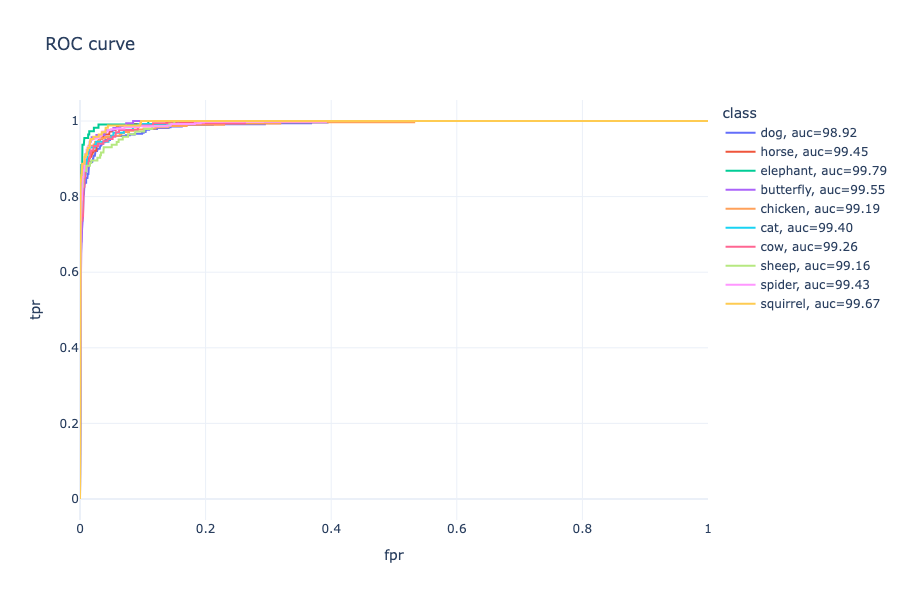

In [16]:
df = pd.DataFrame(df_dict)
px.line(df, x='fpr', y='tpr', color='class', 
        width=800, height=600, title="ROC curve")

Let's try to tune the threshold for the dog class (which has index 0)

In [17]:
with torch.no_grad():
    val_pred_probs = []
    val_pred_classes = []
    val_true_classes = []
    for batch_x, batch_y in tqdm.tqdm(val_loader):
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        preds_t = torch.argmax(probs_t, -1)
        val_true_classes.extend(batch_y.detach().numpy())
        val_pred_classes.extend(preds_t.detach().numpy())
        val_pred_probs.extend(probs_t.detach().numpy())
val_pred_probs = np.array(val_pred_probs)
val_pred_classes = np.array(val_pred_classes)
val_true_classes = np.array(val_true_classes)
print(classification_report(val_true_classes, val_pred_classes, target_names=images_classes_en))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [01:01<00:00,  3.24s/it]

              precision    recall  f1-score   support

         dog       0.88      0.90      0.89       477
       horse       0.88      0.90      0.89       246
    elephant       0.92      0.85      0.89       101
   butterfly       0.85      0.89      0.87       174
     chicken       0.93      0.93      0.93       326
         cat       0.84      0.89      0.86       136
         cow       0.91      0.84      0.88       199
       sheep       0.75      0.90      0.82       130
      spider       0.96      0.91      0.94       449
    squirrel       0.93      0.85      0.89       183

    accuracy                           0.89      2421
   macro avg       0.88      0.89      0.88      2421
weighted avg       0.90      0.89      0.89      2421



In [18]:
true_dog = (val_true_classes == 0).astype(np.int32)
probs_dog = val_pred_probs[:, 0]

In [19]:
precision, recall, threshold = precision_recall_curve(true_dog, probs_dog)

In [20]:
f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
idx = np.argmax(f1)
best_threshold = threshold[idx]
best_f1 = f1[idx]
best_threshold, best_f1

(np.float32(0.5755095), np.float64(0.9032943676439522))

In [21]:
import matplotlib.pylab as plt
import itertools

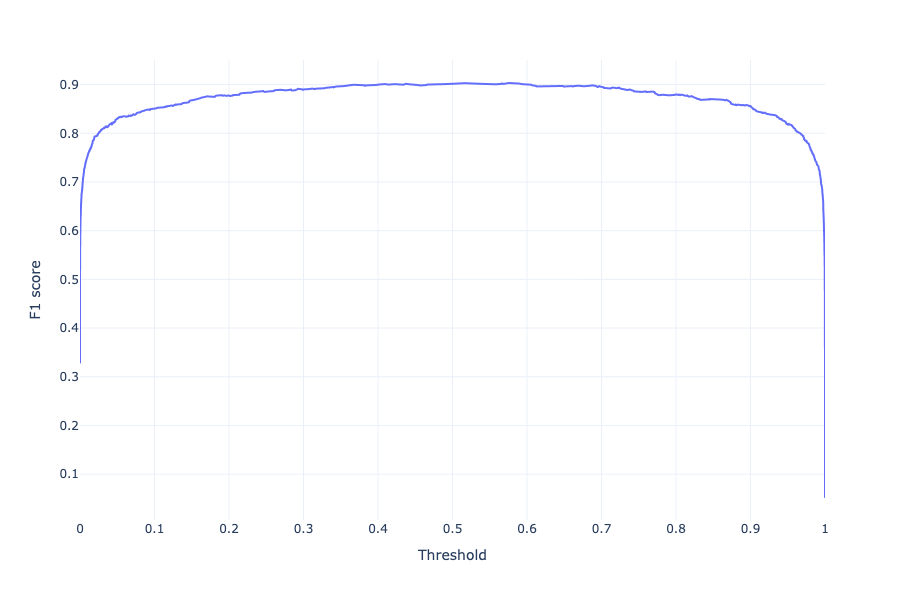

In [23]:
px.line(x=threshold, y=f1, width=800, height=600, 
        labels={"x": "Threshold", "y": "F1 score"})

Compute thresholds for all classes

In [24]:
df_dict = {"threshold": [], "f1": [], "class": []}
class_thresholds = {}
for i, class_name in enumerate(images_classes_en):
    true_i = (val_true_classes == i).astype(np.int32)
    precision, recall, threshold = precision_recall_curve(
        true_i, val_pred_probs[:, i])
    f1 = 2*precision[:-1]*recall[:-1] / (precision[:-1] + recall[:-1] + 1e-10)
    idx = np.argmax(f1)
    best_threshold = threshold[idx]
    best_f1 = f1[idx]
    print(f"{class_name:15s} best F1={best_f1*100:.2f}%, "
          f"threshold={best_threshold:.5f}")
    label = f"{class_name}, f1={best_f1*100:.2f}%"
    df_dict['threshold'].extend(threshold)
    df_dict['f1'].extend(f1)
    df_dict['class'].extend([label for _ in range(len(f1))])
    class_thresholds[i] = best_threshold

dog             best F1=90.33%, threshold=0.57551
horse           best F1=89.75%, threshold=0.52718
elephant        best F1=88.66%, threshold=0.50627
butterfly       best F1=88.29%, threshold=0.77238
chicken         best F1=93.15%, threshold=0.48995
cat             best F1=88.46%, threshold=0.82330
cow             best F1=88.12%, threshold=0.23411
sheep           best F1=89.07%, threshold=0.80928
spider          best F1=94.48%, threshold=0.22165
squirrel        best F1=89.66%, threshold=0.44460


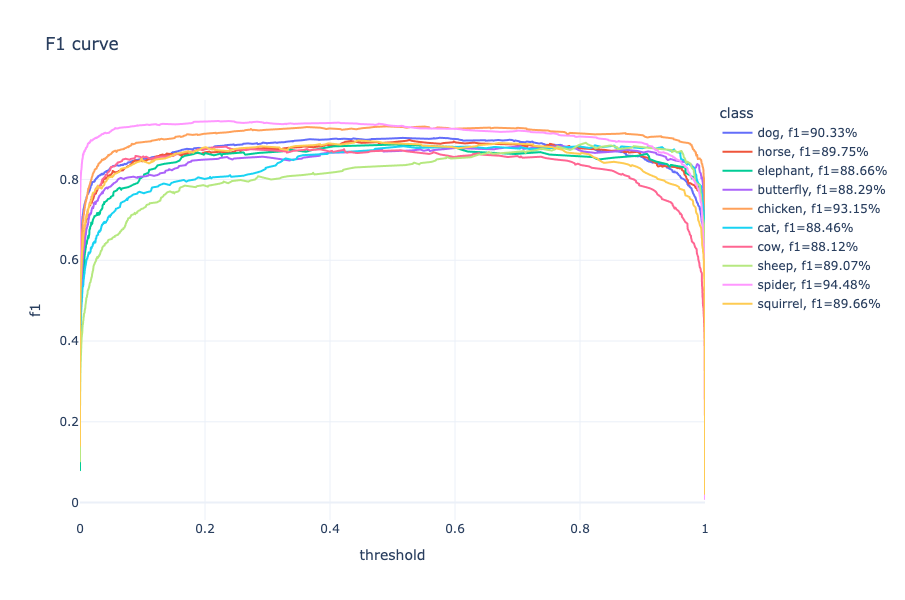

In [25]:
df = pd.DataFrame(df_dict)
px.line(df, x='threshold', y='f1', color='class', 
        width=800, height=600, title="F1 curve")

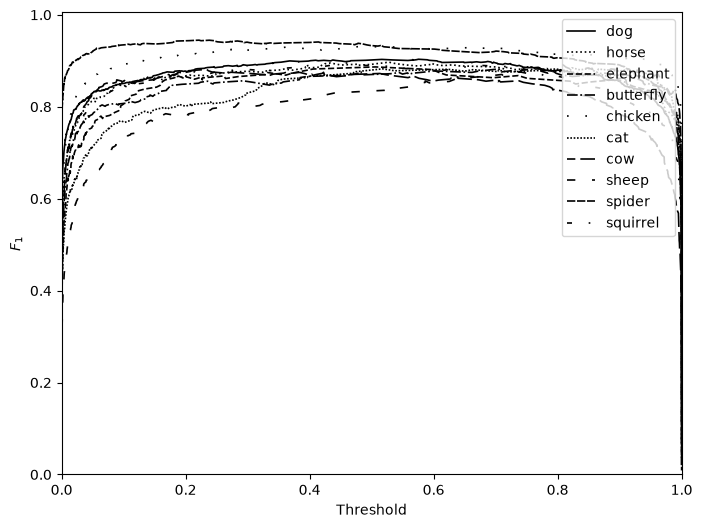

In [27]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
styles = ["solid", "dotted", "dashed", "dashdot", 
          (0, (1, 10)), (0, (1, 1)), (5, (10, 3)), (0, (5, 10)), (0, (5, 1)), (0, (3, 10, 1, 10))]
for style, class_name in zip(styles, images_classes_en):
    sub_df = df[df['class'].str.startswith(class_name)]
    threshold = sub_df.threshold
    f1 = sub_df.f1
    ax.plot(threshold, f1, linestyle=style, color='black', lw=1.2)
ax.legend(images_classes_en, loc='upper right')
ax.set_xlabel("Threshold")
ax.set_ylabel("$F_1$")
ax.set_xlim(0.0, 1)
ax.set_ylim(0.0, 1.005)
fig.savefig("resnet-f1-threshold-all.svg")

# Perform classification using thresholds
With thresholds, our model can now produce "UNKNOWN" result (if all predictions are below threshold)

In [28]:
def denorm_image(img: np.ndarray) -> np.ndarray:
    res = np.array(img, copy=True)
    res = res.transpose((1, 2, 0))
    res *= np.array(data.NORM_STD) * 255
    res += np.array(data.NORM_MEAN) * 255
    res = res.astype(np.uint8)
    return res

In [29]:
with torch.no_grad():
    pred_probs = []
    pred_classes = []
    true_classes = []
    uncertains = []
    for batch_x, batch_y in test_loader:
        out_t = model(batch_x)
        probs_t = torch.softmax(out_t, -1)
        probs = probs_t.detach().numpy()
        batch_classes = batch_y.detach().numpy()
        for row_idx, true_class in enumerate(batch_classes):
            classes = []
            argmax_class = np.argmax(probs[row_idx])
            for class_idx in range(len(images_classes)):
                p = probs[row_idx, class_idx]
                if p > class_thresholds[class_idx]:
                    classes.append((p, class_idx))
            if len(classes) == 0:
                if len(uncertains) < 10:
                    print(f"Uncertain about {images_classes_en[true_class]}, "
                          f"argmax class {images_classes_en[argmax_class]}")
                uncertains.append(denorm_image(batch_x[row_idx].detach().numpy()))
            elif len(classes) == 1:
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
            elif len(classes) > 1:
                classes.sort(reverse=True)
                c, p = classes[0]
                pred_classes.append(p)
                pred_probs.append(c)
                true_classes.append(true_class)
len(uncertains), len(test_dataset)

Uncertain about spider, argmax class butterfly
Uncertain about horse, argmax class sheep
Uncertain about spider, argmax class squirrel
Uncertain about butterfly, argmax class butterfly
Uncertain about cat, argmax class cat
Uncertain about dog, argmax class sheep
Uncertain about squirrel, argmax class cat
Uncertain about chicken, argmax class chicken
Uncertain about cat, argmax class cat
Uncertain about cow, argmax class dog


(113, 2421)

In [30]:
print(classification_report(true_classes, pred_classes, target_names=images_classes_en))

              precision    recall  f1-score   support

         dog       0.94      0.94      0.94       446
       horse       0.92      0.92      0.92       246
    elephant       0.92      0.97      0.95       107
   butterfly       0.92      0.92      0.92       153
     chicken       0.92      0.95      0.93       298
         cat       0.89      0.93      0.91       118
         cow       0.91      0.88      0.89       160
       sheep       0.93      0.89      0.91       134
      spider       0.96      0.94      0.95       489
    squirrel       0.95      0.95      0.95       157

    accuracy                           0.93      2308
   macro avg       0.93      0.93      0.93      2308
weighted avg       0.93      0.93      0.93      2308



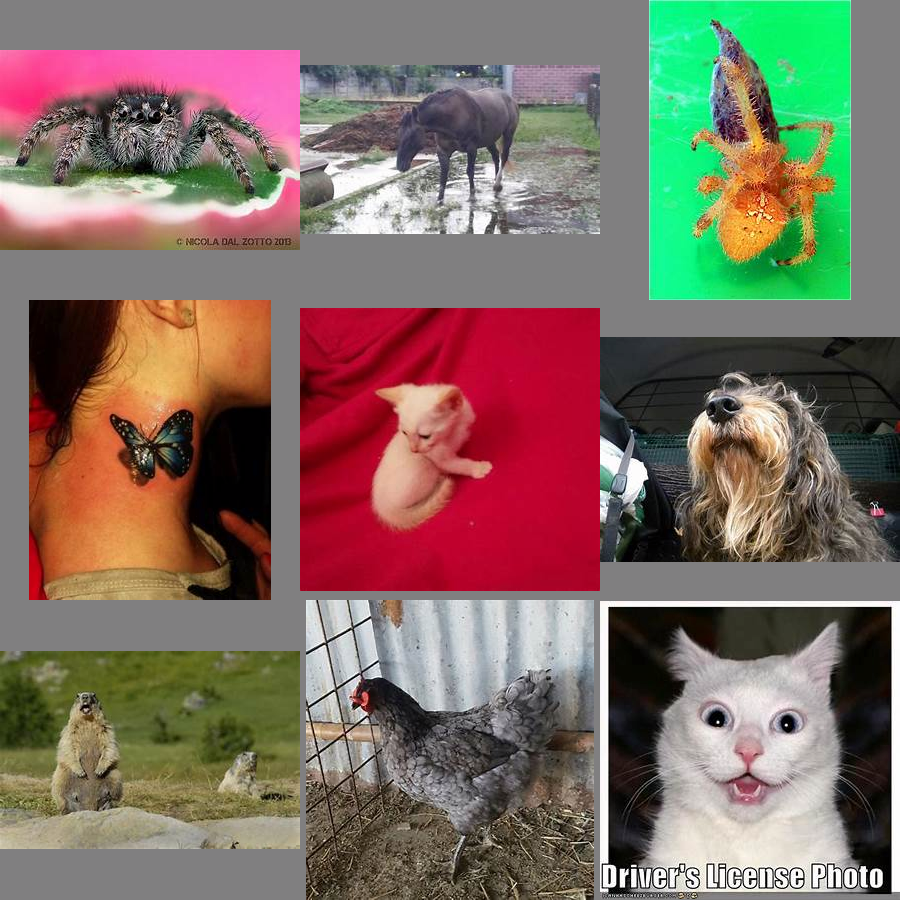

In [31]:
grid = Image.new("RGB", (3*300, 3*300), "white")
for row in range(3): 
    for col in range(3):
        grid.paste(Image.fromarray(uncertains[row*3+col]), (col*300, row*300))
grid

In [32]:
grid.save("uncertain-resnet.png")